# Mock photo-z / selection-function checks

Compare angular correlation of spec mocks in `/global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5` to Quaia data in $0.8 < z < 2.1$.

Mock variants per realization:
- `mock_catalog_quaia_nosel_G20.5.fits` (no selection)
- `mock_catalog_quaia_G20.5_with_zspec.fits` (spectroscopic $z$)
- `mock_catalog_quaia_G20.5.fits` (photo-z selection)


In [1]:
import glob
import os
import time

import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import astropy.cosmology
from astropy.table import Table
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.mocks.DDrppi_mocks import DDrppi_mocks
from Corrfunc.utils import convert_3d_counts_to_cf, convert_rp_pi_counts_to_wp

import sys
sys.path.insert(0, '../code')
import correlations

%load_ext autoreload
%autoreload 2


In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rc('text', usetex=False)


In [3]:
# --- configuration (nosel / zspec / photoz order) ---
G_max = 20.5
zmin, zmax = 0.8, 2.1
z_col = 'redshift_quaia'  # data, nosel, photoz
MOCK_Z_COL = {
    'nosel': 'redshift_quaia',
    'zspec': 'redshift_quaia_spec',
    'photoz': 'redshift_quaia',
}
tag_quaia_zclust = '_zmin0.8zmax2.1'
fac_rand = 10
# Shared uniform-sky pool (sel func = ones; size = fac_rand * N(quaia_G20.5)).
# Regenerate from code/:  python generate_random.py uniform_pool --overwrite
fn_rand_uniform_pool = f'../data/randoms/random_G{G_max}_{fac_rand}x_uniform.fits'

MOCK_BASE = '/global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5'
MOCK_TYPES = {
    'nosel': 'mock_catalog_quaia_nosel_G20.5.fits',
    'zspec': 'mock_catalog_quaia_G20.5_with_zspec.fits',
    'photoz': 'mock_catalog_quaia_G20.5.fits',
}
MOCK_TYPE_LABELS = {
    'nosel': 'photo-$z$, no sel effects',
    'zspec': 'spectroscopic $z$, sel effects (~corrected)',
    'photoz': 'photo-$z$, sel effects (~corrected)',
}
MOCK_COLORS = {
    'nosel': 'forestgreen',
    'zspec': 'royalblue',
    'photoz': 'purple',
}
MOCK_LINESTYLES = {
    'nosel': '-',
    'zspec': '--',
    'photoz': '-.',
}
MOCK_TYPE_KEYS = ['nosel', 'zspec', 'photoz']
MOCK_TYPE_KEYS_UNCORR = ['zspec_uncorr', 'photoz_uncorr']
MOCK_TYPES['photoz_uncorr'] = MOCK_TYPES['photoz']
MOCK_TYPES['zspec_uncorr'] = MOCK_TYPES['zspec']
MOCK_TYPE_LABELS['photoz_uncorr'] = 'photo-$z$, sel effects (uncorrected)'
MOCK_TYPE_LABELS['zspec_uncorr'] = 'spectroscopic $z$, sel effects (uncorrected)'
MOCK_COLORS['photoz_uncorr'] = 'darkviolet'
MOCK_COLORS['zspec_uncorr'] = 'steelblue'
MOCK_LINESTYLES['photoz_uncorr'] = ':'
MOCK_LINESTYLES['zspec_uncorr'] = ':'
MOCK_TYPE_KEYS_ALL = MOCK_TYPE_KEYS + MOCK_TYPE_KEYS_UNCORR

N_mocks = 4
nthreads = 16
theta_edges = np.logspace(-2.5, -0.25, 16)
theta = 0.5 * (theta_edges[1:] + theta_edges[:-1])
SKY_SUBSAMPLE = 50000

# wp(rp) binning (Mpc/h)
n_rp_bins = 14
rp_edges = np.logspace(np.log10(1), np.log10(200), n_rp_bins + 1)
rp = 0.5 * (rp_edges[1:] + rp_edges[:-1])
pimax = 100
cosmology = 2
is_comoving_dist = True
wp_rand_seed = 42


## Functions


In [4]:
def sky_arrays(ra, dec):
    return np.asarray(ra, dtype=np.float64), np.asarray(dec, dtype=np.float64)


def z_col_for_mock(mock_key):
    base = mock_key.removesuffix('_uncorr')
    return MOCK_Z_COL[base]


def apply_z_cut(tab, zmin, zmax, z_col=z_col):
    mask = (tab[z_col] > zmin) & (tab[z_col] < zmax)
    return tab[mask]


_tab_rand_uniform_pool = None


def load_uniform_random_pool(fn_pool=fn_rand_uniform_pool):
    global _tab_rand_uniform_pool
    if _tab_rand_uniform_pool is None:
        _tab_rand_uniform_pool = Table.read(fn_pool)
        print(f'Uniform random pool: {fn_pool}  N={len(_tab_rand_uniform_pool)}')
    return _tab_rand_uniform_pool


def subsample_randoms(tab, n_target, seed=wp_rand_seed):
    if len(tab) == n_target:
        return tab
    if len(tab) < n_target:
        raise ValueError(f'Random pool N={len(tab)} < n_target={n_target}')
    rng = np.random.default_rng(seed)
    return tab[rng.choice(len(tab), size=n_target, replace=False)]


def uniform_randoms_for_n_data(n_data, fac_rand=fac_rand, seed=wp_rand_seed,
                               fn_pool=fn_rand_uniform_pool):
    """Subsample shared uniform pool to fac_rand * n_data."""
    pool = load_uniform_random_pool(fn_pool)
    n_target = int(fac_rand * n_data)
    tab = subsample_randoms(pool, n_target, seed=seed)
    print(f'Uniform randoms (subsampled): N={len(tab)} = {fac_rand}x {n_data}')
    return tab


def load_quaia_data_and_randoms(G_max=G_max, tag_z=tag_quaia_zclust,
                                zmin_load=None, zmax_load=None, fac_rand=fac_rand,
                                fn_pool=fn_rand_uniform_pool, seed_uniform=wp_rand_seed):
    """Load data + sel randoms for a z-slice; uniform randoms from shared pool."""
    if zmin_load is None:
        zmin_load = zmin
    if zmax_load is None:
        zmax_load = zmax
    fn_data = f'../data/quaia_G{G_max}{tag_z}.fits'
    fn_rand_sel = (
        f'../data/randoms/random_G{G_max}_zmin{zmin_load}zmax{zmax_load}_{fac_rand}x.fits')
    tab_data = Table.read(fn_data)
    tab_rand_sel = Table.read(fn_rand_sel)
    tab_rand_uniform = uniform_randoms_for_n_data(
        len(tab_data), fac_rand=fac_rand, seed=seed_uniform, fn_pool=fn_pool)
    print(f'Data: {fn_data}  N={len(tab_data)}')
    print(f'Randoms (sel func): {fn_rand_sel}  N={len(tab_rand_sel)}')
    return tab_data, tab_rand_sel, tab_rand_uniform


def tab_rand_for_mock(mock_key):
    if mock_key in ('nosel', 'photoz_uncorr', 'zspec_uncorr'):
        return tab_rand_uniform
    return tab_rand_sel


def discover_mock_paths(mock_base, mock_filename, n_mocks=None):
    """Find mock*/<mock_filename> under mock_base (one path per realization dir)."""
    if n_mocks is None:
        n_mocks = N_mocks
    pattern = os.path.join(mock_base, 'mock*', mock_filename)
    paths = sorted(glob.glob(pattern))
    if len(paths) == 0:
        raise RuntimeError(f'No mocks found: {pattern}')
    n_avail = len(paths)
    if n_mocks is not None and n_avail < n_mocks:
        print(f'WARNING: requested n_mocks={n_mocks} but only {n_avail} found for {mock_filename}')
    if n_mocks is not None:
        paths = paths[:n_mocks]
    print(f'Using {len(paths)}/{n_avail} available mocks for {mock_filename}')
    for p in paths:
        print(' ', p)
    return paths


def compute_rr_theta(theta_edges, ra_rand, dec_rand, nthreads=nthreads):
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    start = time.time()
    RR_theta = DDtheta_mocks(1, nthreads, theta_edges, ra_rand, dec_rand)
    print(f'RR theta time: {time.time() - start:.4f} s')
    return RR_theta


def compute_wtheta_ls(ra, dec, ra_rand, dec_rand, theta_edges, RR_theta,
                      nthreads=nthreads, verbose=True):
    ra, dec = sky_arrays(ra, dec)
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    if verbose:
        start = time.time()
    DD_theta = DDtheta_mocks(1, nthreads, theta_edges, ra, dec)
    if verbose:
        print(f'  DD theta time: {time.time() - start:.4f} s')
        start = time.time()
    DR_theta = DDtheta_mocks(0, nthreads, theta_edges, ra, dec,
                             RA2=ra_rand, DEC2=dec_rand)
    if verbose:
        print(f'  DR theta time: {time.time() - start:.4f} s')
    N, N_rand = len(ra), len(ra_rand)
    return convert_3d_counts_to_cf(N, N, N_rand, N_rand,
                                   DD_theta, DR_theta, DR_theta, RR_theta)


def compute_wtheta_data(tab_data, tab_rand, theta_edges, RR_theta, nthreads=nthreads):
    return compute_wtheta_ls(tab_data['ra'], tab_data['dec'],
                             tab_rand['ra'], tab_rand['dec'],
                             theta_edges, RR_theta, nthreads=nthreads)


def compute_mock_ensemble_wtheta(mock_paths, tab_rand, theta_edges, RR_theta,
                                 mock_key, zmin=zmin, zmax=zmax, nthreads=nthreads):
    z_col_mock = z_col_for_mock(mock_key)
    ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
    wtheta_list = []
    for i, path in enumerate(mock_paths):
        tab = apply_z_cut(Table.read(path), zmin, zmax, z_col=z_col_mock)
        print(f'Mock {i+1}/{len(mock_paths)}: {path} ({z_col_mock}) -> N(zcut)={len(tab)}')
        wtheta_list.append(
            compute_wtheta_ls(tab['ra'], tab['dec'], ra_rand, dec_rand,
                              theta_edges, RR_theta, nthreads=nthreads))
    return np.array(wtheta_list)


def summarize_ensemble(arr):
    """Mean and 16/84 percentiles over mock realizations."""
    return {
        'mean': np.mean(arr, axis=0),
        'p16': np.percentile(arr, 16, axis=0),
        'p84': np.percentile(arr, 84, axis=0),
    }


def summarize_wtheta_ensemble(wtheta_mocks):
    return summarize_ensemble(wtheta_mocks)
    return {
        'mean': np.mean(wtheta_mocks, axis=0),
        'p16': np.percentile(wtheta_mocks, 16, axis=0),
        'p84': np.percentile(wtheta_mocks, 84, axis=0),
    }

def comoving_dist_mpc_h(z, cosmo=None):
    """Comoving distance in Mpc/h for Corrfunc (is_comoving_dist=True)."""
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    return cosmo.comoving_distance(np.asarray(z)).value * cosmo.h


def setup_wp_random_distances(tab_ref, tab_rand, z_col_ref=z_col, seed=wp_rand_seed,
                              cosmo=None):
    """Draw redshifts with replacement from tab_ref onto tab_rand (never uniform z)."""
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    rng = np.random.default_rng(seed)
    z_rand = rng.choice(tab_ref[z_col_ref], size=len(tab_rand), replace=True)
    return cosmo, comoving_dist_mpc_h(z_rand, cosmo)


def compute_rr_rp(rp_edges, pimax, ra_rand, dec_rand, dist_rand,
                  cosmology=cosmology, nthreads=nthreads,
                  is_comoving_dist=is_comoving_dist):
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    dist_rand = np.asarray(dist_rand, dtype=np.float64)
    start = time.time()
    RR_rp = DDrppi_mocks(1, cosmology, nthreads, pimax, rp_edges,
                         ra_rand, dec_rand, dist_rand,
                         is_comoving_dist=is_comoving_dist)
    print(f'RR rp time: {time.time() - start:.4f} s')
    return RR_rp


def compute_wp_ls(ra, dec, dist, ra_rand, dec_rand, dist_rand, rp_edges, pimax, RR_rp,
                  cosmology=cosmology, nthreads=nthreads, verbose=True,
                  is_comoving_dist=is_comoving_dist):
    """Landy-Szalay wp(rp) reusing precomputed RR(rp, pi)."""
    ra, dec = sky_arrays(ra, dec)
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    dist = np.asarray(dist, dtype=np.float64)
    dist_rand = np.asarray(dist_rand, dtype=np.float64)
    n_rpbins = len(rp_edges) - 1
    if verbose:
        start = time.time()
    DD_rp = DDrppi_mocks(1, cosmology, nthreads, pimax, rp_edges, ra, dec, dist,
                         is_comoving_dist=is_comoving_dist)
    if verbose:
        print(f'  DD rp time: {time.time() - start:.4f} s')
        start = time.time()
    DR_rp = DDrppi_mocks(0, cosmology, nthreads, pimax, rp_edges, ra, dec, dist,
                         RA2=ra_rand, DEC2=dec_rand, CZ2=dist_rand,
                         is_comoving_dist=is_comoving_dist)
    if verbose:
        print(f'  DR rp time: {time.time() - start:.4f} s')
    N, N_rand = len(ra), len(ra_rand)
    return convert_rp_pi_counts_to_wp(N, N, N_rand, N_rand,
                                      DD_rp, DR_rp, DR_rp, RR_rp,
                                      n_rpbins, pimax)


def compute_wp_data(tab_data, tab_rand, dist_rand_shared, rp_edges, pimax, RR_rp,
                    z_col_data=z_col, cosmo=None, nthreads=nthreads):
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    dist_data = comoving_dist_mpc_h(tab_data[z_col_data], cosmo)
    return compute_wp_ls(tab_data['ra'], tab_data['dec'], dist_data,
                         tab_rand['ra'], tab_rand['dec'], dist_rand_shared,
                         rp_edges, pimax, RR_rp, nthreads=nthreads)


def compute_mock_ensemble_wp(mock_paths, tab_rand, dist_rand_shared, rp_edges, pimax, RR_rp,
                             mock_key, zmin=zmin, zmax=zmax, cosmo=None, nthreads=nthreads):
    z_col_mock = z_col_for_mock(mock_key)
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
    wp_list = []
    for i, path in enumerate(mock_paths):
        tab = apply_z_cut(Table.read(path), zmin, zmax, z_col=z_col_mock)
        dist = comoving_dist_mpc_h(tab[z_col_mock], cosmo)
        print(f'Mock {i+1}/{len(mock_paths)}: {path} ({z_col_mock}) -> N(zcut)={len(tab)}')
        wp_list.append(
            compute_wp_ls(tab['ra'], tab['dec'], dist, ra_rand, dec_rand, dist_rand_shared,
                          rp_edges, pimax, RR_rp, nthreads=nthreads))
    return np.array(wp_list)


## Load data and shared randoms


In [5]:
tab_data, tab_rand_sel, tab_rand_uniform = load_quaia_data_and_randoms()
ra_rand_sel, dec_rand_sel = tab_rand_sel['ra'], tab_rand_sel['dec']
ra_rand_uniform, dec_rand_uniform = tab_rand_uniform['ra'], tab_rand_uniform['dec']
print('theta_edges:', theta_edges)


Uniform random pool: ../data/randoms/random_G20.5_10x_uniform.fits  N=12955020
Uniform randoms (subsampled): N=8145610 = 10x 814561
Data: ../data/quaia_G20.5_zmin0.8zmax2.1.fits  N=814561
Randoms (sel func): ../data/randoms/random_G20.5_zmin0.8zmax2.1_10x.fits  N=8141884
theta_edges: [0.00316228 0.00446684 0.00630957 0.00891251 0.01258925 0.01778279
 0.02511886 0.03548134 0.05011872 0.07079458 0.1        0.14125375
 0.19952623 0.28183829 0.39810717 0.56234133]


## Visualizations


In [6]:
# viz: one realization per type (ensemble uses N_mocks below)
viz_tabs = {'data': tab_data}
for mock_key in MOCK_TYPE_KEYS:
    path = discover_mock_paths(MOCK_BASE, MOCK_TYPES[mock_key], n_mocks=1)[0]
    zc = z_col_for_mock(mock_key)
    viz_tabs[mock_key] = apply_z_cut(Table.read(path), zmin, zmax, z_col=zc)
    print(f'{mock_key} ({zc}): N(z-cut)={len(viz_tabs[mock_key])}')


Using 1/1 available mocks for mock_catalog_quaia_nosel_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits
nosel (redshift_quaia): N(z-cut)=814564
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits
zspec (redshift_quaia_spec): N(z-cut)=817074
Using 1/1 available mocks for mock_catalog_quaia_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits
photoz (redshift_quaia): N(z-cut)=814540


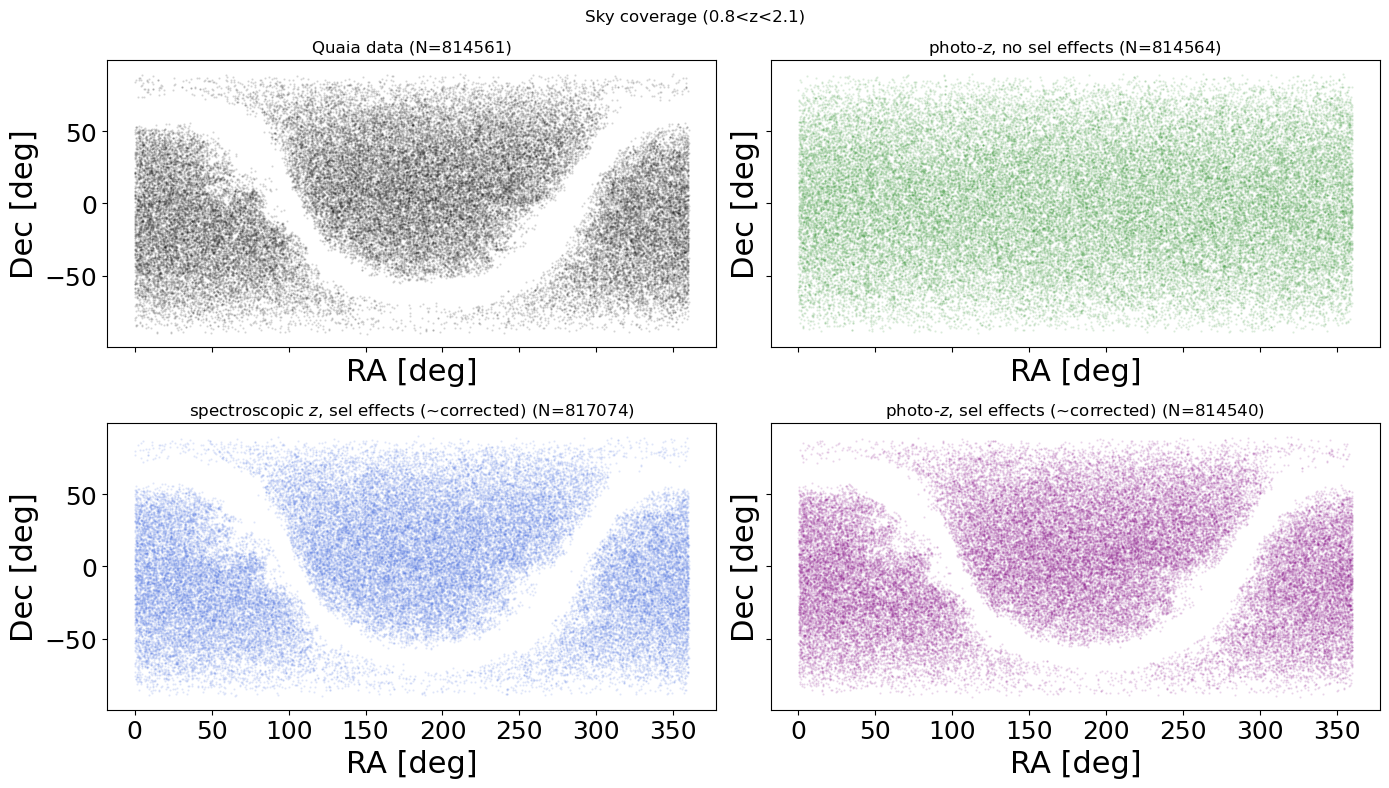

In [7]:
def subsample_tab(tab, n_max=SKY_SUBSAMPLE, seed=42):
    if len(tab) <= n_max:
        return tab
    rng = np.random.default_rng(seed)
    return tab[rng.choice(len(tab), size=n_max, replace=False)]

panels = [('data', 'Quaia data', 'black')]
panels += [(k, MOCK_TYPE_LABELS[k], MOCK_COLORS[k]) for k in MOCK_TYPE_KEYS]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, (key, label, color) in zip(axes.flat, panels):
    t = subsample_tab(viz_tabs[key])
    ax.scatter(t['ra'], t['dec'], s=0.3, alpha=0.15, c=color, rasterized=True)
    ax.set_title(f'{label} (N={len(viz_tabs[key])})')
    ax.set_xlabel('RA [deg]'); ax.set_ylabel('Dec [deg]')
fig.suptitle(f'Sky coverage ({zmin}<z<{zmax})')
fig.tight_layout(); plt.show()


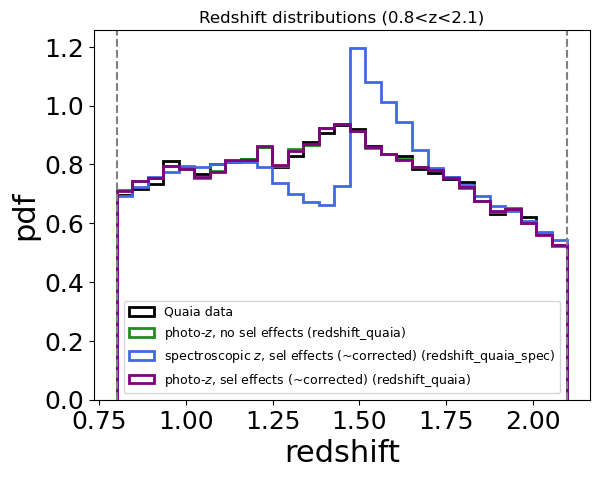

In [8]:
z_bins = np.linspace(zmin, zmax, 30)

fig, ax = plt.subplots()
ax.hist(tab_data[z_col], bins=z_bins, histtype='step', lw=2, color='black',
        density=True, label='Quaia data')
for mock_key in MOCK_TYPE_KEYS:
    zc = z_col_for_mock(mock_key)
    ax.hist(viz_tabs[mock_key][zc], bins=z_bins, histtype='step', lw=2,
            color=MOCK_COLORS[mock_key], density=True,
            label=f"{MOCK_TYPE_LABELS[mock_key]} ({zc})")
ax.axvline(zmin, color='grey', ls='--'); ax.axvline(zmax, color='grey', ls='--')
ax.set_xlabel('redshift'); ax.set_ylabel('pdf'); ax.legend(fontsize=9)
ax.set_title(f'Redshift distributions ({zmin}<z<{zmax})')
plt.show()


In [9]:
RR_theta_sel = compute_rr_theta(theta_edges, ra_rand_sel, dec_rand_sel, nthreads=nthreads)
RR_theta_uniform = compute_rr_theta(theta_edges, ra_rand_uniform, dec_rand_uniform, nthreads=nthreads)


[Warning] The CPU supports AVX2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports AVX but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSSE3 but the compiler does not.  Can you try another compiler?


RR theta time: 43.7499 s
RR theta time: 34.4465 s


In [10]:
wtheta_data = compute_wtheta_data(tab_data, tab_rand_sel, theta_edges, RR_theta_sel, nthreads=nthreads)
print('N data =', len(tab_data))


  DD theta time: 0.6971 s
  DR theta time: 11.6988 s
N data = 814561


## Mock ensembles ($w(\theta)$)


In [11]:
wtheta_results = {}
N_mocks_used_wtheta = {}
for mock_key in MOCK_TYPE_KEYS:
    print(f'\n=== {mock_key} (z col: {z_col_for_mock(mock_key)}) ===')
    tab_rand = tab_rand_for_mock(mock_key)
    RR_theta = RR_theta_uniform if mock_key == 'nosel' else RR_theta_sel
    paths = discover_mock_paths(MOCK_BASE, MOCK_TYPES[mock_key], n_mocks=N_mocks)
    N_mocks_used_wtheta[mock_key] = len(paths)
    wtheta_mocks = compute_mock_ensemble_wtheta(
        paths, tab_rand, theta_edges, RR_theta, mock_key=mock_key)
    wtheta_results[mock_key] = {'paths': paths, 'wtheta_mocks': wtheta_mocks,
                                  **summarize_ensemble(wtheta_mocks)}
print('N_mocks requested:', N_mocks)
print('N_mocks used per type:', N_mocks_used_wtheta)



=== nosel (z col: redshift_quaia) ===
Using 1/1 available mocks for mock_catalog_quaia_nosel_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits (redshift_quaia) -> N(zcut)=814564


  DD theta time: 0.6073 s
  DR theta time: 9.5904 s

=== zspec (z col: redshift_quaia_spec) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits (redshift_quaia_spec) -> N(zcut)=817074
  DD theta time: 0.7205 s
  DR theta time: 11.6652 s

=== photoz (z col: redshift_quaia) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits (redshift_quaia) -> N(zcut)=814540
  DD theta time: 0.7166 s
  DR theta time: 11.6456 s
N_mocks requested: 4
N_mocks used per type: {'nosel': 1, 'zspec': 1, 'photoz': 1}


## Uncorrected sel-effects mocks (uniform-sky randoms)

Same catalogs as photo-z / spec-z (~corrected), but uniform-sky randoms from `random_G20.5_10x_uniform.fits` (subsampled to `fac_rand` × N_data). $w_p$ redshifts are still drawn from Quaia data, shuffled onto those positions.


In [14]:
# Uncorrected sel-effects mocks: same catalogs as photoz/zspec, uniform-sky randoms
# Run after RR_theta_uniform (above). wp(rp) for these types is computed in the wp ensemble cell below.

for mock_key in MOCK_TYPE_KEYS_UNCORR:
    print(f'\n=== {mock_key} (z col: {z_col_for_mock(mock_key)}, uniform-sky randoms) ===')
    tab_rand = tab_rand_for_mock(mock_key)
    paths = discover_mock_paths(MOCK_BASE, MOCK_TYPES[mock_key], n_mocks=N_mocks)
    N_mocks_used_wtheta[mock_key] = len(paths)
    wtheta_mocks = compute_mock_ensemble_wtheta(
        paths, tab_rand, theta_edges, RR_theta_uniform, mock_key=mock_key)
    wtheta_results[mock_key] = {'paths': paths, 'wtheta_mocks': wtheta_mocks,
                                  **summarize_ensemble(wtheta_mocks)}

print('Added uncorrected types:', MOCK_TYPE_KEYS_UNCORR)
print('Plot keys:', MOCK_TYPE_KEYS_ALL)


=== zspec_uncorr (z col: redshift_quaia_spec, uniform-sky randoms) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits (redshift_quaia_spec) -> N(zcut)=817074
  DD theta time: 0.7098 s
  DR theta time: 9.4418 s

=== photoz_uncorr (z col: redshift_quaia, uniform-sky randoms) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits (redshift_quaia) -> N(zcut)=814540
  DD theta time: 0.6995 s
  DR theta time: 9.3854 s
Added uncorrected types: ['zspec_uncorr', 'photoz_uncorr']
Plot keys: ['nosel', 'zspec', 'photoz', 'zspec_uncorr', 'photoz_uncor

## Plot: mock means vs data (all 3 types)


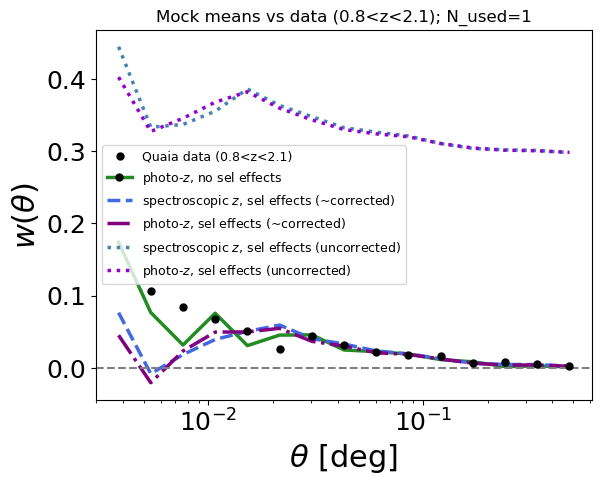

In [15]:
fig, ax = plt.subplots()
ax.plot(theta, wtheta_data, color='black', marker='o', linestyle='none', markersize=5,
        label=f'Quaia data ({zmin}<z<{zmax})', zorder=10)
MOCK_TYPE_KEYS_PLOT = MOCK_TYPE_KEYS + ['zspec_uncorr', 'photoz_uncorr']
for mock_key in MOCK_TYPE_KEYS_PLOT:
    if mock_key not in wtheta_results:
        continue
    ax.plot(theta, wtheta_results[mock_key]['mean'], color=MOCK_COLORS[mock_key],
            linestyle=MOCK_LINESTYLES[mock_key], lw=2.5,
            label=MOCK_TYPE_LABELS[mock_key])
ax.set_xscale('log'); ax.axhline(0, color='grey', ls='--')
ax.set_xlabel(r'$\theta$ [deg]'); ax.set_ylabel(r'$w(\theta)$')
ax.legend(fontsize=9)
n_used = min(N_mocks_used_wtheta.values()) if N_mocks_used_wtheta else 0
ax.set_title(f'Mock means vs data ({zmin}<z<{zmax}); N_used={n_used}')
plt.show()


## $w_p(r_p)$


In [7]:
cosmo, dist_rand_sel = setup_wp_random_distances(tab_data, tab_rand_sel)
cosmo, dist_rand_uniform = setup_wp_random_distances(tab_data, tab_rand_uniform, cosmo=cosmo)
dist_rand_by_type = {'sel': dist_rand_sel, 'uniform': dist_rand_uniform}
ra_rand_wp_sel, dec_rand_wp_sel = tab_rand_sel['ra'], tab_rand_sel['dec']
ra_rand_wp_uniform, dec_rand_wp_uniform = tab_rand_uniform['ra'], tab_rand_uniform['dec']
print('rp_edges:', rp_edges)


rp_edges: [  1.           1.46002162   2.13166312   3.11227423   4.54398764
   6.63432018   9.68625086  14.14213562  20.64782369  30.1462689
  44.01420421  64.26168951  93.82345571 136.98427334 200.        ]


In [8]:
RR_rp_sel = compute_rr_rp(rp_edges, pimax, ra_rand_wp_sel, dec_rand_wp_sel, dist_rand_sel)
RR_rp_uniform = compute_rr_rp(rp_edges, pimax, ra_rand_wp_uniform, dec_rand_wp_uniform, dist_rand_uniform)
RR_rp_by_type = {'sel': RR_rp_sel, 'uniform': RR_rp_uniform}


[Warning] The CPU supports AVX2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports AVX but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSSE3 but the compiler does not.  Can you try another compiler?


RR rp time: 328.5592 s
RR rp time: 254.8159 s


In [9]:
wp_data = compute_wp_data(tab_data, tab_rand_sel, dist_rand_sel, rp_edges, pimax, RR_rp_sel, cosmo=cosmo)
print('N data =', len(tab_data))


  DD rp time: 4.1182 s


  DR rp time: 76.5332 s
N data = 814561


## Mock ensembles ($w_p$)


In [10]:
wp_results = {}
N_mocks_used_wp = {}
wp_keys = MOCK_TYPE_KEYS + MOCK_TYPE_KEYS_UNCORR
for mock_key in wp_keys:
    print(f'\n=== wp {mock_key} (z col: {z_col_for_mock(mock_key)}) ===')
    tab_rand = tab_rand_for_mock(mock_key)
    rand_type = 'uniform' if mock_key in ('nosel', 'photoz_uncorr', 'zspec_uncorr') else 'sel'
    paths = discover_mock_paths(MOCK_BASE, MOCK_TYPES[mock_key], n_mocks=N_mocks)
    N_mocks_used_wp[mock_key] = len(paths)
    wp_mocks = compute_mock_ensemble_wp(
        paths, tab_rand, dist_rand_by_type[rand_type], rp_edges, pimax, RR_rp_by_type[rand_type],
        mock_key=mock_key, cosmo=cosmo)
    wp_results[mock_key] = {'paths': paths, 'wp_mocks': wp_mocks,
                            **summarize_ensemble(wp_mocks)}
print('N_mocks used per type (wp):', N_mocks_used_wp)


=== wp nosel (z col: redshift_quaia) ===
Using 1/1 available mocks for mock_catalog_quaia_nosel_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits (redshift_quaia) -> N(zcut)=814564


  DD rp time: 3.3782 s
  DR rp time: 59.8315 s

=== wp zspec (z col: redshift_quaia_spec) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits (redshift_quaia_spec) -> N(zcut)=817074
  DD rp time: 4.0737 s
  DR rp time: 75.2634 s

=== wp photoz (z col: redshift_quaia) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits (redshift_quaia) -> N(zcut)=814540
  DD rp time: 4.0673 s
  DR rp time: 75.7088 s

=== wp zspec_uncorr (z col: redshift_quaia_spec) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cd

## Plot: $w_p(r_p)$ mock means vs data


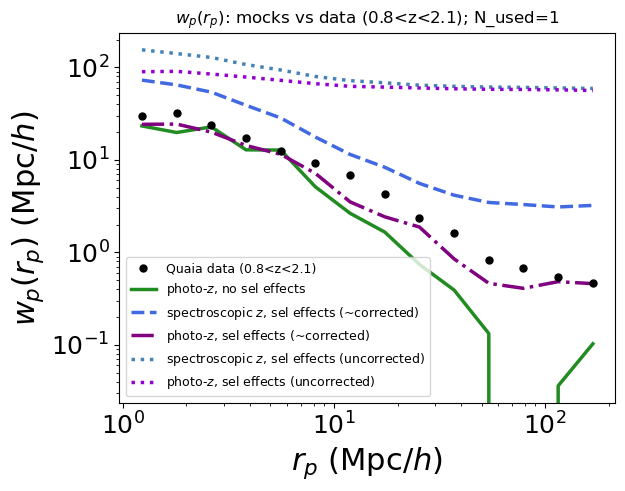

In [11]:
fig, ax = plt.subplots()
ax.plot(rp, wp_data, color='black', marker='o', linestyle='none', markersize=5,
        label=f'Quaia data ({zmin}<z<{zmax})', zorder=10)
MOCK_TYPE_KEYS_PLOT = MOCK_TYPE_KEYS + ['zspec_uncorr', 'photoz_uncorr']
for mock_key in MOCK_TYPE_KEYS_PLOT:
    if mock_key not in wp_results:
        continue
    ax.plot(rp, wp_results[mock_key]['mean'], color=MOCK_COLORS[mock_key],
            linestyle=MOCK_LINESTYLES[mock_key], lw=2.5,
            label=MOCK_TYPE_LABELS[mock_key])
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r_p$ (Mpc/$h$)'); ax.set_ylabel(r'$w_p(r_p)$ (Mpc/$h$)')
ax.legend(fontsize=9)
n_used = min(N_mocks_used_wp.values()) if N_mocks_used_wp else 0
ax.set_title(f'$w_p(r_p)$: mocks vs data ({zmin}<z<{zmax}); N_used={n_used}')
plt.show()


## $w_p(r_p)$ vs $\pi_{\max}$ (three mock types)

Ensemble $w_p$ for **no sel effects**, **spec-$z$ corrected**, and **photo-$z$ corrected** at $\pi_{\max} = 100$, $500$, and $1000$ Mpc/$h$. The $\pi_{\max}=100$ curves reuse `wp_results` when available; larger $\pi_{\max}$ need new RR and mock DD/DR counts.

In [12]:
MOCK_TYPE_KEYS_PIMAX = ['nosel', 'zspec', 'photoz']
PIMAX_VALUES = [100, 500, 1000]

wp_by_pimax = {}
for pimax_val in PIMAX_VALUES:
    print(f'\n=== pi_max = {pimax_val} Mpc/h ===')
    if pimax_val == pimax:
        RR_rp_local = RR_rp_by_type
        print('Reusing RR(rp) and mock wp from above (pimax=100).')
    else:
        RR_rp_local = {
            'sel': compute_rr_rp(rp_edges, pimax_val, ra_rand_wp_sel, dec_rand_wp_sel, dist_rand_sel),
            'uniform': compute_rr_rp(
                rp_edges, pimax_val, ra_rand_wp_uniform, dec_rand_wp_uniform, dist_rand_uniform),
        }

    wp_by_pimax[pimax_val] = {}
    for mock_key in MOCK_TYPE_KEYS_PIMAX:
        if pimax_val == pimax and mock_key in wp_results:
            wp_by_pimax[pimax_val][mock_key] = wp_results[mock_key]
            print(f'  {mock_key}: reused wp ensemble')
            continue
        tab_rand = tab_rand_for_mock(mock_key)
        rand_type = 'uniform' if mock_key == 'nosel' else 'sel'
        paths = wp_results[mock_key]['paths'] if mock_key in wp_results else discover_mock_paths(
            MOCK_BASE, MOCK_TYPES[mock_key], n_mocks=N_mocks)
        wp_mocks = compute_mock_ensemble_wp(
            paths, tab_rand, dist_rand_by_type[rand_type], rp_edges, pimax_val,
            RR_rp_local[rand_type], mock_key=mock_key, cosmo=cosmo)
        wp_by_pimax[pimax_val][mock_key] = {'paths': paths, 'wp_mocks': wp_mocks,
                                            **summarize_ensemble(wp_mocks)}


=== pi_max = 100 Mpc/h ===
Reusing RR(rp) and mock wp from above (pimax=100).
  nosel: reused wp ensemble
  zspec: reused wp ensemble
  photoz: reused wp ensemble

=== pi_max = 500 Mpc/h ===
RR rp time: 1806.0567 s


RuntimeError: RuntimeError occurred

In [ ]:
import matplotlib.colors as mcolors

def shade_color(color, frac):
    """Blend base color with white; frac=1 is full color, frac=0 is white."""
    r, g, b = mcolors.to_rgb(color)
    return tuple(frac * c + (1.0 - frac) for c in (r, g, b))

# lighter (small pi_max) -> darker (large pi_max)
PIMAX_SHADE = {100: 0.40, 500: 0.70, 1000: 1.0}

fig, ax = plt.subplots()
for pimax_val in PIMAX_VALUES:
    frac = PIMAX_SHADE[pimax_val]
    for mock_key in MOCK_TYPE_KEYS_PIMAX:
        wp_mean = wp_by_pimax[pimax_val][mock_key]['mean']
        ax.plot(
            rp, wp_mean,
            color=shade_color(MOCK_COLORS[mock_key], frac),
            linestyle=MOCK_LINESTYLES[mock_key],
            lw=2.5,
            label=f"{MOCK_TYPE_LABELS[mock_key]}, $\\pi_{{\\max}}={pimax_val}$",
        )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r_p$ (Mpc/$h$)')
ax.set_ylabel(r'$w_p(r_p)$ (Mpc/$h$)')
ax.legend(fontsize=8, ncol=1)
n_used = (min(N_mocks_used_wp[k] for k in MOCK_TYPE_KEYS_PIMAX)
          if N_mocks_used_wp else N_mocks)
ax.set_title(
    rf'$w_p(r_p)$ vs $\pi_{{\max}}$ ({zmin}<z<{zmax}); '
    f'lighter$\rightarrow$darker = {PIMAX_VALUES}; N_used={n_used}')
plt.show()

## $w_p(r_p)$ vs $\pi_{\max}$ — $0 < z < 1$ bin (corrected mocks)

Self-contained: loads Quaia + randoms for $0<z<1$ (sel randoms per slice; uniform from shared `random_G20.5_10x_uniform.fits`, subsampled to `fac_rand` × N_data). Computes $w_p$ at $\pi_{\max}\in\{100,500,1000\}$ Mpc/$h$ for **nosel / zspec / photoz** only. Requires imports, config, and **Functions** cells above.

In [6]:
# --- 0 < z < 1: configuration ---
zmin_z01, zmax_z01 = 0.0, 1.0
tag_z01 = '_zmin0.0zmax1.0'
MOCK_KEYS_Z01 = ['nosel', 'zspec', 'photoz']
PIMAX_VALUES_Z01 = [100, 500, 1000]
wp_rand_seed_z01 = wp_rand_seed  # same seed convention as main notebook

In [7]:
tab_data_z01, tab_rand_sel_z01, tab_rand_uniform_z01 = load_quaia_data_and_randoms(
    tag_z=tag_z01, zmin_load=zmin_z01, zmax_load=zmax_z01, seed_uniform=wp_rand_seed_z01)

Uniform randoms (subsampled): N=3243360 = 10x 324336
Data: ../data/quaia_G20.5_zmin0.0zmax1.0.fits  N=324336
Randoms (sel func): ../data/randoms/random_G20.5_zmin0.0zmax1.0_10x.fits  N=3242045


In [8]:
def tab_rand_z01(mock_key):
    return tab_rand_uniform_z01 if mock_key == 'nosel' else tab_rand_sel_z01


cosmo_z01, dist_rand_sel_z01 = setup_wp_random_distances(
    tab_data_z01, tab_rand_sel_z01, z_col_ref=z_col, seed=wp_rand_seed_z01)
_, dist_rand_uniform_z01 = setup_wp_random_distances(
    tab_data_z01, tab_rand_uniform_z01, z_col_ref=z_col, seed=wp_rand_seed_z01, cosmo=cosmo_z01)
dist_rand_by_type_z01 = {'sel': dist_rand_sel_z01, 'uniform': dist_rand_uniform_z01}
ra_rand_sel_z01, dec_rand_sel_z01 = tab_rand_sel_z01['ra'], tab_rand_sel_z01['dec']
ra_rand_uniform_z01, dec_rand_uniform_z01 = (
    tab_rand_uniform_z01['ra'], tab_rand_uniform_z01['dec'])
print('wp random distances ready')

wp random distances ready


In [9]:
mock_paths_z01 = {
    k: discover_mock_paths(MOCK_BASE, MOCK_TYPES[k], n_mocks=N_mocks)
    for k in MOCK_KEYS_Z01
}
N_mocks_used_wp_z01 = {k: len(mock_paths_z01[k]) for k in MOCK_KEYS_Z01}
print('N_mocks per type:', N_mocks_used_wp_z01)

Using 1/1 available mocks for mock_catalog_quaia_nosel_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits
Using 1/1 available mocks for mock_catalog_quaia_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits
N_mocks per type: {'nosel': 1, 'zspec': 1, 'photoz': 1}


In [ ]:
wp_by_pimax_z01 = {}
RR_rp_by_pimax_z01 = {}

for pimax_val in PIMAX_VALUES_Z01:
    print(f'\n=== z01: pi_max = {pimax_val} Mpc/h ===')
    RR_rp_by_pimax_z01[pimax_val] = {
        'sel': compute_rr_rp(
            rp_edges, pimax_val, ra_rand_sel_z01, dec_rand_sel_z01, dist_rand_sel_z01),
        'uniform': compute_rr_rp(
            rp_edges, pimax_val, ra_rand_uniform_z01, dec_rand_uniform_z01,
            dist_rand_uniform_z01),
    }
    wp_by_pimax_z01[pimax_val] = {}
    for mock_key in MOCK_KEYS_Z01:
        tab_rand = tab_rand_z01(mock_key)
        rand_type = 'uniform' if mock_key == 'nosel' else 'sel'
        paths = mock_paths_z01[mock_key]
        wp_mocks = compute_mock_ensemble_wp(
            paths, tab_rand, dist_rand_by_type_z01[rand_type],
            rp_edges, pimax_val, RR_rp_by_pimax_z01[pimax_val][rand_type],
            mock_key=mock_key, zmin=zmin_z01, zmax=zmax_z01, cosmo=cosmo_z01)
        wp_by_pimax_z01[pimax_val][mock_key] = {
            'paths': paths, 'wp_mocks': wp_mocks, **summarize_ensemble(wp_mocks),
        }

print('Done z01 wp_by_pimax:', list(wp_by_pimax_z01.keys()))


=== z01: pi_max = 100 Mpc/h ===


[Warning] The CPU supports AVX2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports AVX but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSSE3 but the compiler does not.  Can you try another compiler?


RR rp time: 111.4573 s
RR rp time: 95.5020 s
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits (redshift_quaia) -> N(zcut)=327836
  DD rp time: 1.7416 s
  DR rp time: 23.8012 s
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits (redshift_quaia_spec) -> N(zcut)=321099
  DD rp time: 1.9603 s
  DR rp time: 27.1125 s
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits (redshift_quaia) -> N(zcut)=327842
  DD rp time: 2.0866 s
  DR rp time: 28.1335 s

=== z01: pi_max = 500 Mpc/h ===
RR rp time: 928.9952 s
RR rp time: 784.4030 s
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits (redshift_quaia) -> N(zcut)=327836
  DD rp time: 10.7701 s
  DR rp time: 176.6986 s
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_wit

In [ ]:
import matplotlib.colors as mcolors

def shade_color_z01(color, frac):
    r, g, b = mcolors.to_rgb(color)
    return tuple(frac * c + (1.0 - frac) for c in (r, g, b))

PIMAX_SHADE_Z01 = {100: 0.40, 500: 0.70, 1000: 1.0}

fig, ax = plt.subplots()
for pimax_val in PIMAX_VALUES_Z01:
    frac = PIMAX_SHADE_Z01[pimax_val]
    for mock_key in MOCK_KEYS_Z01:
        wp_mean = wp_by_pimax_z01[pimax_val][mock_key]['mean']
        ax.plot(
            rp, wp_mean,
            color=shade_color_z01(MOCK_COLORS[mock_key], frac),
            linestyle=MOCK_LINESTYLES[mock_key],
            lw=2.5,
            label=f"{MOCK_TYPE_LABELS[mock_key]}, $\\pi_{{\\max}}={pimax_val}$",
        )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r_p$ (Mpc/$h$)')
ax.set_ylabel(r'$w_p(r_p)$ (Mpc/$h$)')
ax.legend(fontsize=8, ncol=1)
n_used = min(N_mocks_used_wp_z01.values())
ax.set_title(
    rf'$w_p(r_p)$ vs $\pi_{{\max}}$ ({zmin_z01}<z<{zmax_z01}); '
    f'lighter$\rightarrow$darker = {PIMAX_VALUES_Z01}; N_used={n_used}')
plt.show()

In [13]:
# Save / load Corrfunc outputs (RR counts, w(theta), wp, ensembles).
# After compute cells: SAVE_CORRFUNC_CACHE=True, LOAD=False → writes/updates cache.
# Fresh kernel, skip Corrfunc: run config + functions + data load, then
#   LOAD_CORRFUNC_CACHE=True, SAVE=False → run this cell before plot cells.

import pickle
from pathlib import Path

CORRFUNC_CACHE_DIR = Path('../data/cache/mock_photoz_selfunc_checks')
LOAD_CORRFUNC_CACHE = False   # restore from disk if cache exists
SAVE_CORRFUNC_CACHE = True    # merge in-memory results into cache

# Names written when present in the kernel (partial saves are OK).
CORRFUNC_CACHE_KEYS = [
    'RR_theta_sel', 'RR_theta_uniform',
    'RR_rp_sel', 'RR_rp_uniform', 'RR_rp_by_type',
    'RR_rp_by_pimax',  # optional dict: pimax -> {'sel': array, 'uniform': array}
    'dist_rand_sel', 'dist_rand_uniform', 'dist_rand_by_type',
    'wtheta_data', 'wp_data',
    'wtheta_results', 'wp_results', 'wp_by_pimax',
    'N_mocks_used_wtheta', 'N_mocks_used_wp',
]


def corrfunc_cache_path():
    pimax_scan = ''
    if 'PIMAX_VALUES' in globals():
        pimax_scan = '_scan' + '-'.join(str(int(p)) for p in PIMAX_VALUES)
    tag = (
        f'G{G_max}_z{zmin}_{zmax}_Nm{N_mocks}_nth{len(theta_edges) - 1}'
        f'_nrp{n_rp_bins}_pimax{pimax}{pimax_scan}_seed{wp_rand_seed}.pkl'
    )
    return CORRFUNC_CACHE_DIR / tag


def _corrfunc_cache_meta():
    return {
        'G_max': G_max, 'zmin': zmin, 'zmax': zmax, 'N_mocks': N_mocks,
        'nthreads': nthreads, 'wp_rand_seed': wp_rand_seed, 'pimax': pimax,
        'theta_edges': np.asarray(theta_edges), 'rp_edges': np.asarray(rp_edges),
    }


def collect_corrfunc_cache():
    bundle = {'meta': _corrfunc_cache_meta()}
    present = []
    for key in CORRFUNC_CACHE_KEYS:
        if key in globals():
            bundle[key] = globals()[key]
            present.append(key)
    bundle['meta']['keys_saved'] = present
    return bundle


def save_corrfunc_cache(path=None, merge=True):
    CORRFUNC_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = Path(path) if path is not None else corrfunc_cache_path()
    new = collect_corrfunc_cache()
    if merge and path.exists():
        with open(path, 'rb') as f:
            old = pickle.load(f)
        for key, val in new.items():
            if key == 'meta':
                old_meta = old.get('meta', {})
                old_meta.update(val)
                old['meta'] = old_meta
            else:
                old[key] = val
        bundle = old
    else:
        bundle = new
    with open(path, 'wb') as f:
        pickle.dump(bundle, f)
    print(f'Saved Corrfunc cache → {path}')
    print('  keys:', bundle['meta'].get('keys_saved', []))
    return path


def load_corrfunc_cache(path=None):
    path = Path(path) if path is not None else corrfunc_cache_path()
    if not path.exists():
        print(f'No cache at {path}')
        return False
    with open(path, 'rb') as f:
        bundle = pickle.load(f)
    restored = []
    for key, val in bundle.items():
        if key == 'meta':
            continue
        globals()[key] = val
        restored.append(key)
    meta = bundle.get('meta', {})
    print(f'Loaded Corrfunc cache ← {path}')
    print('  meta:', {k: meta[k] for k in meta if k != 'keys_saved'})
    print('  restored:', restored)
    return True


_cache_path = corrfunc_cache_path()
print(f'Cache file: {_cache_path}  (exists={_cache_path.exists()})')

if LOAD_CORRFUNC_CACHE:
    load_corrfunc_cache(_cache_path)
if SAVE_CORRFUNC_CACHE:
    save_corrfunc_cache(_cache_path, merge=True)

Cache file: ../data/cache/mock_photoz_selfunc_checks/G20.5_z0.8_2.1_Nm4_nth15_nrp14_pimax100_scan100-500-1000_seed42.pkl  (exists=False)
Saved Corrfunc cache → ../data/cache/mock_photoz_selfunc_checks/G20.5_z0.8_2.1_Nm4_nth15_nrp14_pimax100_scan100-500-1000_seed42.pkl
  keys: ['RR_rp_sel', 'RR_rp_uniform', 'RR_rp_by_type', 'dist_rand_sel', 'dist_rand_uniform', 'dist_rand_by_type', 'wp_data', 'wp_results', 'wp_by_pimax', 'N_mocks_used_wp']
